In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

In [2]:
# Database credentials
username = 'root'
password = quote_plus('Athira@2801')   # keep quote_plus for special characters
host = '127.0.0.1'
port = 3306
database = 'bharat_herald'

# Create engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("Database connection created successfully!")

Database connection created successfully!


In [3]:
folder_path = r'C:\Users\Hp\Downloads\rpc_17_inputs (1)\rpc_17_inputs\Datasets'

In [4]:
'''
for file in os.listdir(folder_path):

    if file.startswith("~$"):
        continue  # skip temp Excel files

    table_name = None
    file_path = os.path.join(folder_path, file)

    # Handle Excel files
    if file.endswith(".xlsx"):
        table_name = file.replace(".xlsx", "")
        df = pd.read_excel(file_path)

    # Handle CSV files
    elif file.endswith(".csv"):
        table_name = file.replace(".csv", "")
        df = pd.read_csv(file_path)

    else:
        continue  # skip other files like .txt, .ipynb

    # Clean column names
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    # Special cleaning for fact_print_sales
    if table_name == "fact_print_sales":
        numeric_cols = ['copies_sold', 'copies_returned', 'net_circulation']

        for col in numeric_cols:
            if col in df.columns:
                df[col] = (
                    df[col]
                    .astype(str)
                    .str.replace('₹', '', regex=False)
                    .str.replace(',', '', regex=False)
                )
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].fillna(0).astype(int)

    if 'month' in df.columns:
        df['month'] = pd.to_datetime(df['month'], errors='coerce')

    print(f"{table_name} rows before insert:", len(df))

    with engine.begin() as connection:
        df.to_sql(
            table_name,
            con=connection,
            if_exists='append',
            index=False
        )

    print(f"{table_name} loaded successfully!\n")
    '''

'\nfor file in os.listdir(folder_path):\n\n    if file.startswith("~$"):\n        continue  # skip temp Excel files\n\n    table_name = None\n    file_path = os.path.join(folder_path, file)\n\n    # Handle Excel files\n    if file.endswith(".xlsx"):\n        table_name = file.replace(".xlsx", "")\n        df = pd.read_excel(file_path)\n\n    # Handle CSV files\n    elif file.endswith(".csv"):\n        table_name = file.replace(".csv", "")\n        df = pd.read_csv(file_path)\n\n    else:\n        continue  # skip other files like .txt, .ipynb\n\n    # Clean column names\n    df.columns = (\n        df.columns\n        .str.strip()\n        .str.lower()\n        .str.replace(" ", "_")\n    )\n\n    # Special cleaning for fact_print_sales\n    if table_name == "fact_print_sales":\n        numeric_cols = [\'copies_sold\', \'copies_returned\', \'net_circulation\']\n\n        for col in numeric_cols:\n            if col in df.columns:\n                df[col] = (\n                    df[col

In [5]:
tables = [
    'dim_ad_category',
    'dim_city',
    'fact_ad_revenue',
    'fact_city_readiness',
    'fact_digital_pilot',
    'fact_print_sales'
]

with engine.connect() as conn:
    for table in tables:
        result = conn.execute(text(f"SELECT COUNT(*) FROM {table}"))
        print(f"{table} row count:", result.scalar())

dim_ad_category row count: 4
dim_city row count: 10
fact_ad_revenue row count: 720
fact_city_readiness row count: 240
fact_digital_pilot row count: 48
fact_print_sales row count: 720


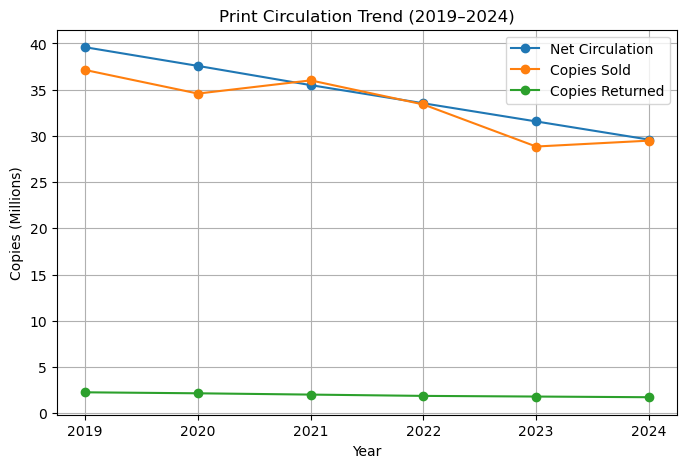

In [55]:
q = """
SELECT 
YEAR(month) AS year,
SUM(net_circulation) AS net_circulation,
SUM(copies_sold) AS copies_sold,
SUM(copies_returned) AS copies_returned
FROM fact_print_sales
GROUP BY year
ORDER BY year;
"""

df_trend = pd.read_sql(q, engine)

plt.figure(figsize=(8,5))

plt.plot(df_trend['year'], df_trend['net_circulation']/1_000_000, marker='o', label='Net Circulation')
plt.plot(df_trend['year'], df_trend['copies_sold']/1_000_000, marker='o', label='Copies Sold')
plt.plot(df_trend['year'], df_trend['copies_returned']/1_000_000, marker='o', label='Copies Returned')

plt.xlabel("Year")
plt.ylabel("Copies (Millions)")
plt.title("Print Circulation Trend (2019–2024)")
plt.legend()
plt.grid(True)

plt.show()

Bharat Herald’s print circulation declined consistently between 2019 and 2024, falling by nearly 25%. This suggests a structural shift away from print media consumption.

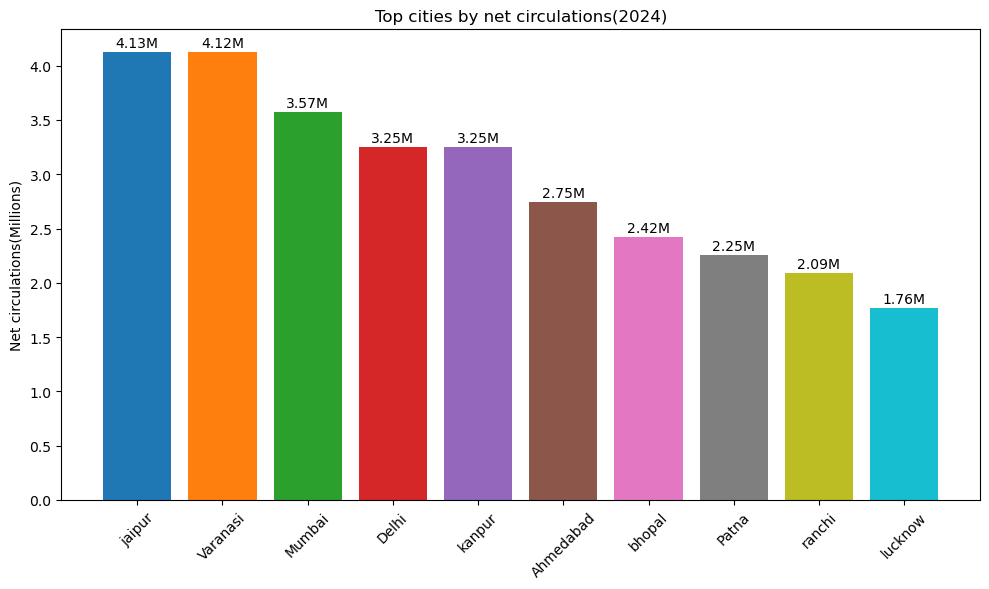

In [8]:
# Top city with most net circulation
q=""" select city, sum(net_circulation) as total_net_circulation 
from fact_print_sales  f join dim_city c on c.city_id = f.city_id
where year(month) = 2024 
group by c.city_id
order by total_net_circulation desc; """
df_topcity= pd.read_sql(text(q),engine)

fig, ax = plt.subplots(figsize=(10,6))

# convert values to decimals
val = df_topcity['total_net_circulation']/1_000_000

colors = plt.cm.tab10(range(len(df_topcity)))

ax.bar(df_topcity['city'], val, color=colors)
plt.xticks(rotation=45)

#add labels
for i, v in enumerate(val):
    ax.text(i, v+ 0.02, f"{v:.2f}M", ha='center', va='bottom')
    
ax.set_title('Top cities by net circulations(2024)')
ax.set_ylabel('Net circulations(Millions)')
plt.tight_layout()
plt.show()

The visualization highlights the cities contributing the highest newspaper circulation in 2024. A few major urban centers dominate distribution, indicating a strong concentration of readership in metropolitan regions.

   year  net_circulation  copies_sold  copies_returned  return_rate
0  2019       39588166.0   37124942.0        2260502.0     5.710045
1  2020       37566841.0   34573433.0        2153120.0     5.731437
2  2021       35488224.0   36001741.0        2013276.0     5.673082
3  2022       33522818.0   33396373.0        1872515.0     5.585792
4  2023       31561283.0   28846124.0        1802057.0     5.709708
5  2024       29597065.0   29482328.0        1728717.0     5.840839


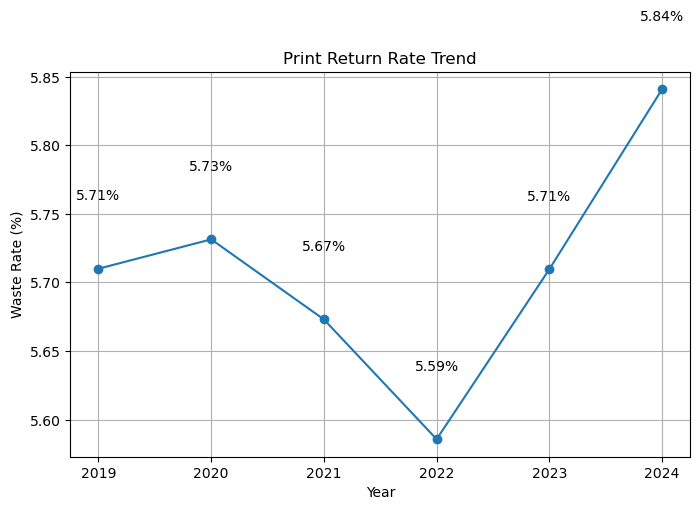

In [9]:
#print return rate trend
import matplotlib.pyplot as plt

df_trend['return_rate'] = df_trend['copies_returned'] / df_trend['net_circulation'] * 100
print(df_trend)

plt.figure(figsize=(8,5))
plt.plot(df_trend['year'], df_trend['return_rate'], marker='o')

plt.xlabel("Year")
plt.ylabel("Waste Rate (%)")
plt.title("Print Return Rate Trend")

#adding values
for x, y in zip(df_trend['year'], df_trend['return_rate']):
    plt.text(x, y+0.05, f"{y:.2f}%", ha= 'center')
    
plt.grid(True)
plt.show()

- Return rates remained relatively stable between 5.58% and 5.84% from 2019–2024.
- The lowest return rate occurred in 2022 (5.58%), indicating the most efficient print distribution.
- However, by 2024 the rate rose again to 5.84%, suggesting growing unsold inventory.

More importantly, net circulation declined from 39.6M to 29.6M (~25% drop), indicating that the core challenge is falling demand for print rather than operational inefficiency.

In [10]:
#ad revnue by category and year
q= """
select 
 case
 when quarter like '____-%%' then left(quarter,4)  
 else right(quarter,4)
 end as year,
 standard_ad_category, round(sum(ad_revenue)) as total_ad_revenue
from fact_ad_revenue  f join dim_ad_category d 
on f.ad_category=d.ad_category_id
group by year, standard_ad_category
order by year;
""" #adding %% in sql like ,to escape from python treating % as formatting symbol
df_adtrend = pd.read_sql(q, engine)

df_adtrend

,year,standard_ad_category,total_ad_revenue
0,2019,Automobile,58348531.0
1,2019,FMCG,66495346.0
2,2019,Government,95749871.0
3,2019,Real Estate,53915991.0
4,2020,Automobile,78758033.0
5,2020,FMCG,27255939.0
6,2020,Government,66326873.0
7,2020,Real Estate,72449275.0
8,2021,Automobile,41289680.0
9,2021,FMCG,48909511.0


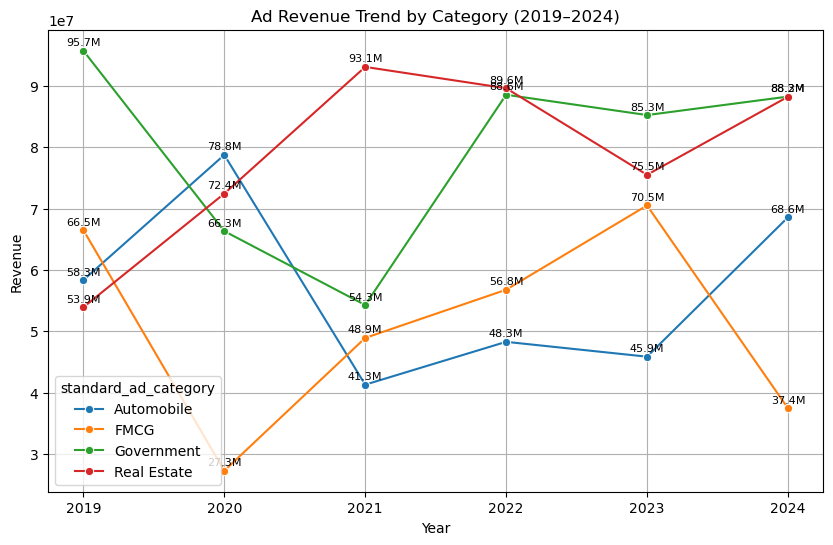

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=df_adtrend,
    x="year",
    y="total_ad_revenue",
    hue="standard_ad_category",
    marker="o"
)

plt.title("Ad Revenue Trend by Category (2019–2024)")
plt.ylabel("Revenue")
plt.xlabel("Year")

# add labels for each category line
for line in ax.lines:
    x = line.get_xdata()
    y = line.get_ydata()
    for i in range(len(x)):
        ax.text(x[i], y[i] + 500000, f'{y[i]/1e6:.1f}M',
                ha='center', va='bottom', fontsize=8)

plt.grid(True)
plt.show()

Government and Real Estate consistently generated the highest advertising revenue during 2019–2024, with Real Estate peaking at around ₹93M in 2021. Advertising trends also reflect pandemic-related shifts: FMCG and Automobile spending declined around 2020, while Real Estate marketing surged during the 2021 market recovery. Government advertising remained relatively stable throughout the period, indicating continuous public communication campaigns.

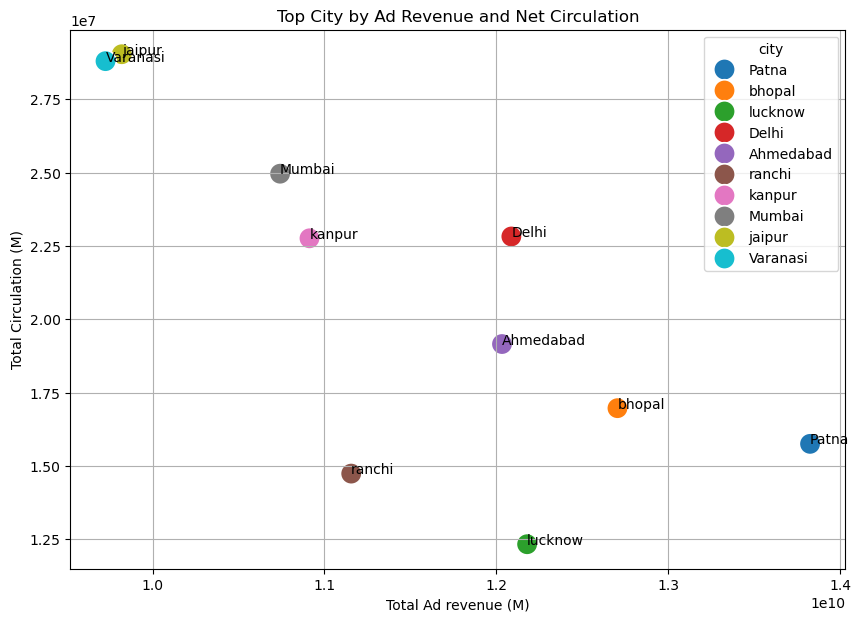

In [60]:
# city level ad revenue performance
q = """ SELECT 
d.city,
SUM(fa.ad_revenue) AS total_ad_revenue,
SUM(fp.net_circulation) AS total_circulation
FROM dim_city d
JOIN fact_print_sales fp 
ON d.city_id = fp.city_id
JOIN (
    SELECT edition_id, SUM(ad_revenue) AS ad_revenue
    FROM fact_ad_revenue
    GROUP BY edition_id
) fa
ON fp.edition_id = fa.edition_id
GROUP BY d.city
ORDER BY total_ad_revenue DESC
LIMIT 10;
"""
df_city= pd.read_sql(q,engine)
df_city

#df_city["ad_revenue_m"] = df_city["total_ad_revenue"] / 1_000_000
#df_city["total_circulation"] = df_city["total_circulation"] / 1_000_000

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_city,
    x="total_ad_revenue",
    y="total_circulation",
    hue="city",
    s=240
)
# city labels
for i in range(len(df_city)):
    plt.text(df_city["total_ad_revenue"][i] + 0.2, df_city["total_circulation"][i], df_city["city"][i])
plt.title("Top City by Ad Revenue and Net Circulation")
plt.xlabel("Total Ad revenue (M)")
plt.ylabel("Total Circulation (M)")

plt.grid(True)
plt.show()

Cities with higher circulation generally generate higher advertising revenue, indicating a positive relationship between readership size and advertiser investment. However, some cities like Patna and Bhopal generate strong ad revenue despite comparatively lower circulation, suggesting higher advertiser demand or stronger local market engagement.

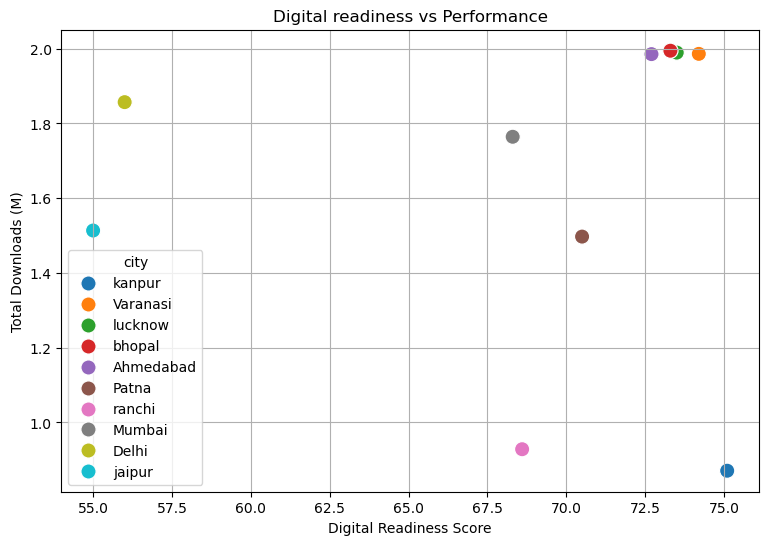

In [61]:
#Digital Readiness vs performance 

q= """ select city, 
ROUND(
 (AVG(r.literacy_rate) + 
  AVG(r.smartphone_penetration) + 
  AVG(r.internet_penetration)) / 3, 1
) AS digital_readiness_score,
SUM(p.users_reached) AS total_users_reached,
SUM(p.downloads_or_accesses) AS total_downloads 
from dim_city c  
join fact_city_readiness r on c.city_id = r.city_id
join  fact_digital_pilot p on r.city_id = p.city_id
group by city
order by digital_readiness_score desc, total_downloads desc;
"""

df_readiness =pd.read_sql(q,engine)
df_readiness

#Visualization
df_readiness["total_downloads_m"] = df_readiness["total_downloads"]/1_000_000
plt.figure(figsize=(9,6))
sns.scatterplot(
    data= df_readiness, x = "digital_readiness_score", y="total_downloads_m",hue="city", s=120)


plt.title("Digital readiness vs Performance")
plt.ylabel("Total Downloads (M)")
plt.xlabel("Digital Readiness Score")

plt.grid(True)
plt.show()

Cities with high digital readiness but lower downloads, such as Kanpur, indicate untapped potential where targeted awareness campaigns and improved user engagement strategies could drive higher digital adoption.

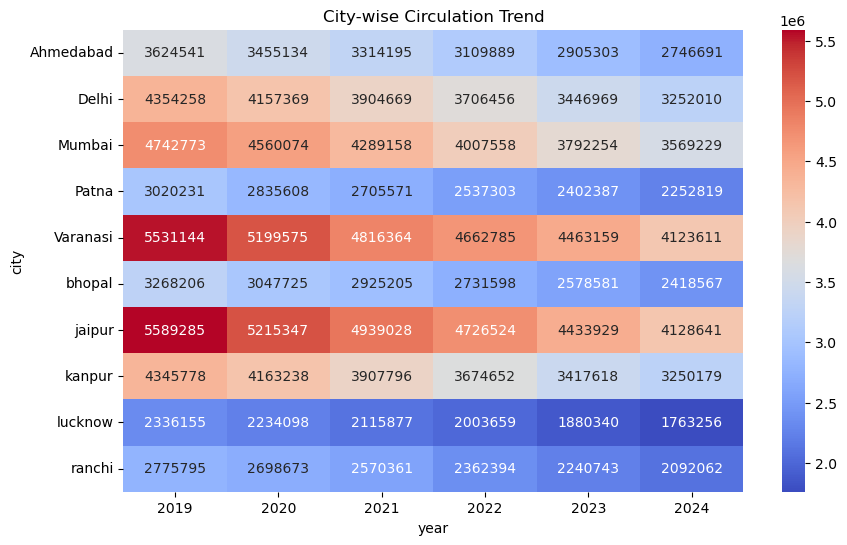

In [51]:
# circulation decline heatmap
q= """SELECT 
c.city,
YEAR(month) AS year,
SUM(net_circulation) AS circulation
FROM fact_print_sales f
JOIN dim_city c
ON f.city_id = c.city_id
GROUP BY c.city, year; """
df_circulation= pd.read_sql(q,engine)

#visualizations
pivot = df_circulation.pivot(
    index="city",
    columns="year",
    values="circulation"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("City-wise Circulation Trend")
plt.show()